<a href="https://colab.research.google.com/github/medistlabo/TCGA_Practice/blob/main/tcga_practice_day15_km.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=dac1efb8f8514ecdbfa6ac834b2cd502ed5e291cc6d5855dc5d1920b1f4ea1f6
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [3]:
data = {
    "patient": ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10","P11","P12"],
    "expression": [5,12,18,25,30,7,40,22,15,35,28,10],
    "survival_month": [50,40,35,20,15,45,10,25,38,12,18,48],
    "status": [0,0,1,1,1,0,1,1,0,1,1,0]
}

df = pd.DataFrame(data)

df

,patient,expression,survival_month,status
0,P1,5,50,0
1,P2,12,40,0
2,P3,18,35,1
3,P4,25,20,1
4,P5,30,15,1
5,P6,7,45,0
6,P7,40,10,1
7,P8,22,25,1
8,P9,15,38,0
9,P10,35,12,1


In [9]:
df["group_median"] = df["expression"].apply(
    lambda x:"High" if x >= df["expression"].median()
    else "Low"
)

In [7]:
kmf = KaplanMeierFitter()

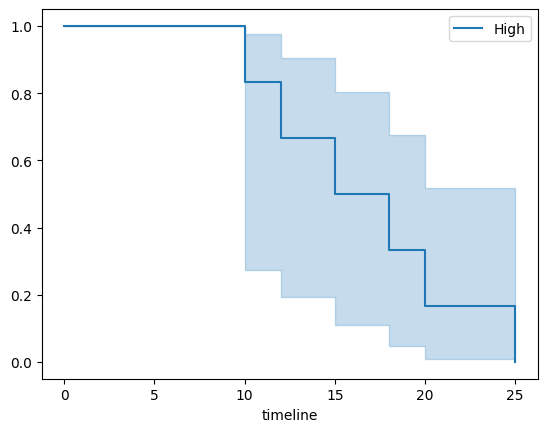

In [11]:
high = df[df["group_median"] == "High"]

kmf.fit(
    durations = high["survival_month"],
    event_observed = high["status"],
    label = "High"
)

kmf.plot()
plt.show()

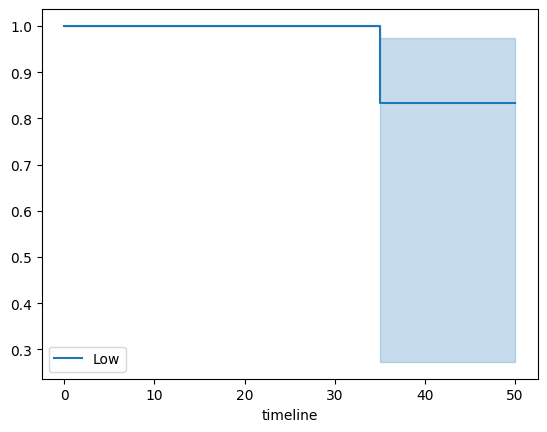

In [12]:
low = df[df["group_median"] == "Low"]

kmf.fit(
    durations=low["survival_month"],
    event_observed=low["status"],
    label="Low"
)

kmf.plot()
plt.show()

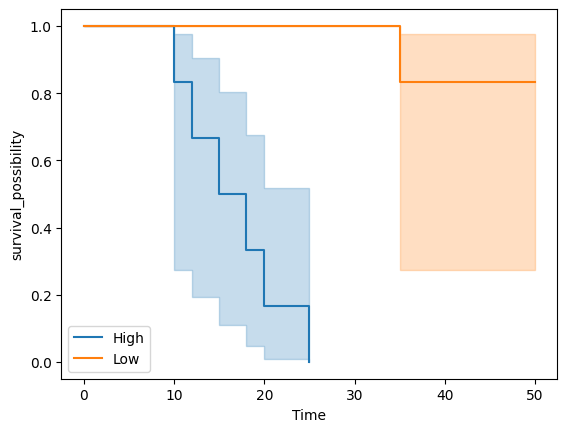

In [13]:
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(
    high["survival_month"],
    high["status"],
    label = "High"
)

kmf_low.fit(
    low["survival_month"],
    low["status"],
    label = "Low"
)

ax = kmf_high.plot()

kmf_low.plot(ax = ax)

plt.xlabel("Time")
plt.ylabel("survival_possibility")

plt.show()